### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
#Creating database connection
conn=sqlite3.connect('inventory.db')

#fetching vendor summary data
df=pd.read_sql_query("SELECT * FROM vendor_sales_summary",conn)
df.shape
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnOver,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,284098.0,1.020384e+07,1345638.62,521998.40,68601.68,6.392587e+06,62.648846,1.958216,2.677293
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,320494.0,9.638147e+06,1123024.74,588877.32,144929.24,5.834106e+06,60.531405,1.953779,2.533660
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,374280.0,9.076241e+06,922280.30,687708.14,123780.22,5.657938e+06,62.337893,1.997151,2.655189
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,400824.0,8.951946e+06,840100.02,736485.60,257032.07,5.690748e+06,63.569954,1.987406,2.744987
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,271676.0,8.446215e+06,1091556.56,499175.66,257032.07,5.423009e+06,64.206382,1.967113,2.793794


In [3]:
df.shape

(10692, 18)

## Exploratory Data Analysis

- Previously, we examined the various tables in the database to identify key variables, understand their relationships and determinewhich one should be included in the final analysis



- In this phase of EDA , we will analyze the resultant table to gain insights into the distributed of each column. The will help us underrstand data patterns, identify anomalies adn ensure data quality before proceding with further analysis

In [141]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnOver', 'SalestoPurchaseRatio',
       'UnitPurchasePrice', 'OrderSize', 'UnsoldInventoryValue',
       'UnsoldUnits'],
      dtype='object')

In [13]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,6154.964272,21905.702782,0.00,66.000000,522.000000,3858.500000,6.698780e+05
TotalSalesDollars,10692.0,84478.148838,335310.531968,0.00,1458.440000,10596.090000,56793.830000,1.020384e+07
TotalSalesPrice,10692.0,37587.567254,89905.546771,0.00,579.420000,5715.600000,32119.125000,1.345639e+06


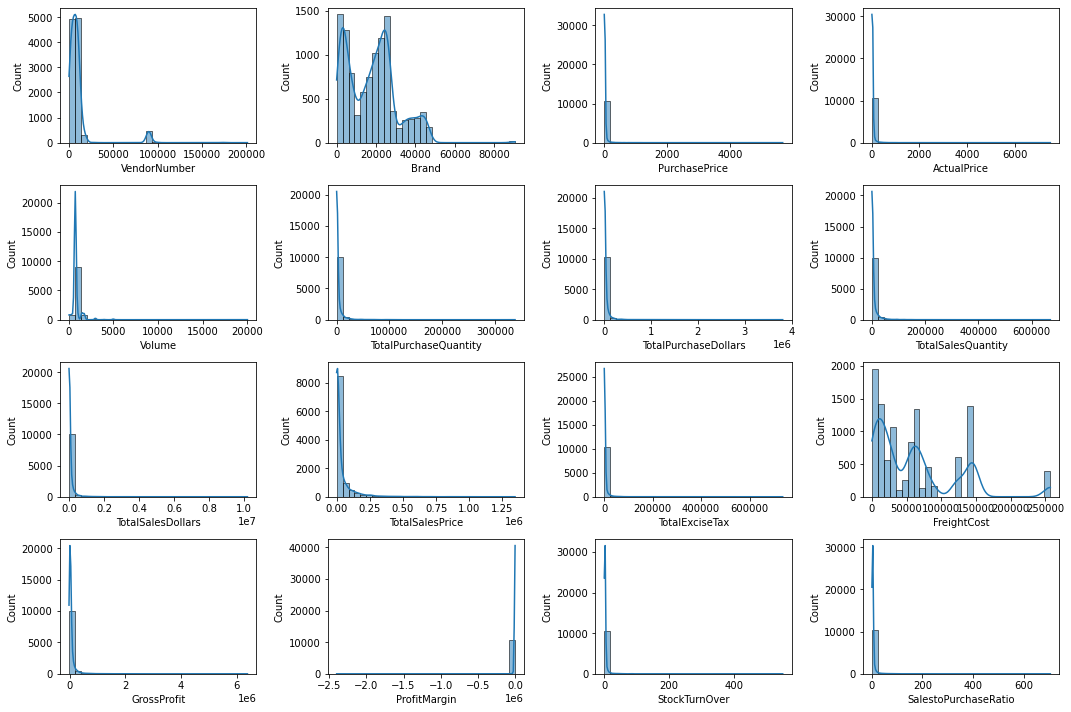

In [14]:
# Distribution plots for Numerical Coumns
numerical_cols= df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) #Adjust grid layout as needed
    sns.histplot(df[col],kde=True, bins=30)
plt.tight_layout()
plt.show()    

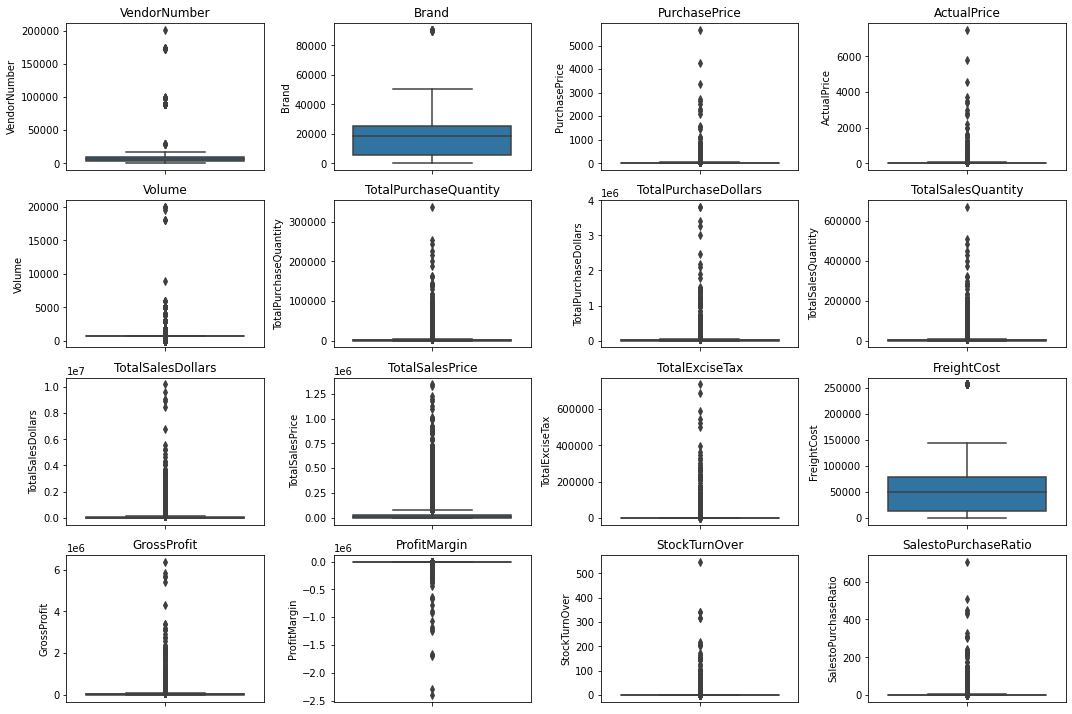

In [18]:
#Outlier Detection with Boxplots
plt.figure(figsize=(15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) #Adjust grid layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()    

### Summary Statistics Insights

#### Negative & Zero Values

- Gross Profit: Minimun value is -31730.24, including  losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.


- Profit Margin: Has a minimum of -2399136, Which suggests cases where revenue is zero or even lower than costs.


- Total Sales Quantity & Sales Dollars: Minimum value are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock

#### Outliers Indicated by High Standard Deviations

- Purchase & Actual Price: The max values (5681.81 & 7499.99) are significantly higher than the mean(24.39 & 35.64), indicating potential premium products.


- Freight Cost: Huge variation, from 0.09 to 257,032.07 ,suggests logistics inefficiencies or bulk shipments.


- Stock Turnover: Range from 0 to 549.0, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to sales are being fulfilled from older stock

In [21]:
#filter the data by removing incosistencies
df =pd.read_sql_query("""
 SELECT *
 FROM vendor_sales_summary
 WHERE GrossProfit > 0
 AND ProfitMargin >0
 AND TotalSalesQuantity > 0
""", conn)

In [22]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnOver,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,284098.0,1.020384e+07,1345638.62,521998.40,68601.68,6.392587e+06,62.648846,1.958216,2.677293
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,320494.0,9.638147e+06,1123024.74,588877.32,144929.24,5.834106e+06,60.531405,1.953779,2.533660
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,374280.0,9.076241e+06,922280.30,687708.14,123780.22,5.657938e+06,62.337893,1.997151,2.655189
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,400824.0,8.951946e+06,840100.02,736485.60,257032.07,5.690748e+06,63.569954,1.987406,2.744987
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,271676.0,8.446215e+06,1091556.56,499175.66,257032.07,5.423009e+06,64.206382,1.967113,2.793794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9810,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,10.0,3.190000e+01,21.92,1.10,27100.41,2.926000e+01,91.724138,5.000000,12.083333
9811,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,268.0,1.313200e+02,2.94,14.08,50293.62,1.289800e+02,98.218093,44.666667,56.119658
9812,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,4.0,3.960000e+00,1.98,0.20,14069.87,2.480000e+00,62.626263,2.000000,2.675676
9813,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,144.0,2.865600e+02,155.22,30.24,257032.07,2.850900e+02,99.487018,144.000000,194.938776


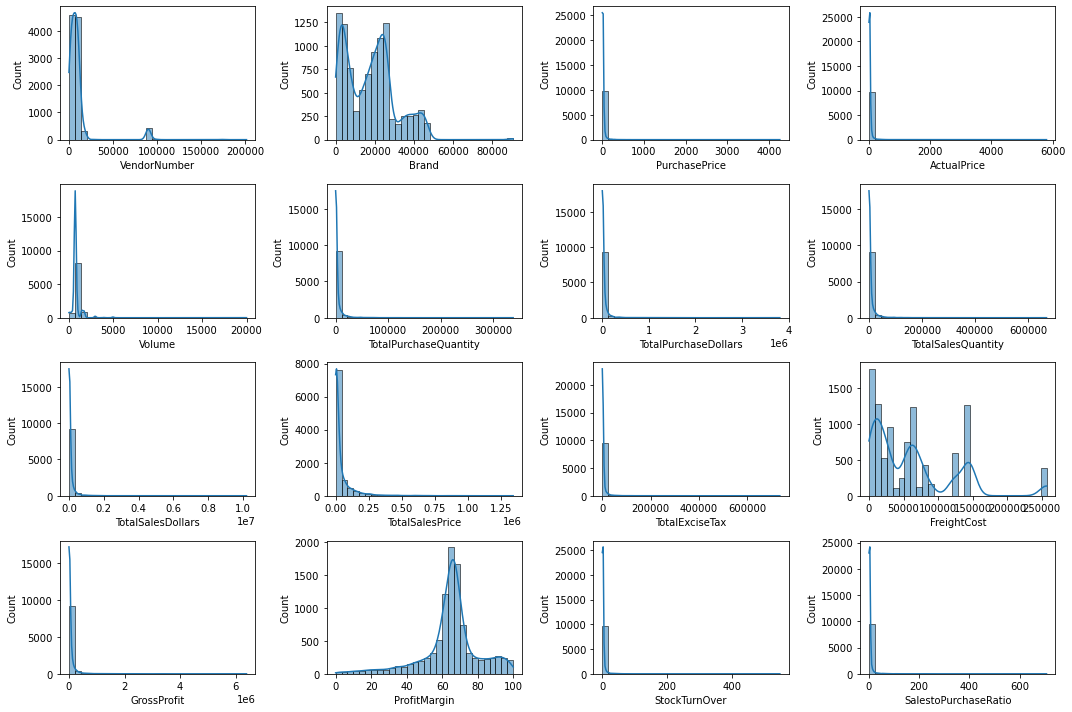

In [23]:
# Distribution plots for Numerical Coumns
numerical_cols= df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1) #Adjust grid layout as needed
    sns.histplot(df[col],kde=True, bins=30)
plt.tight_layout()
plt.show()    

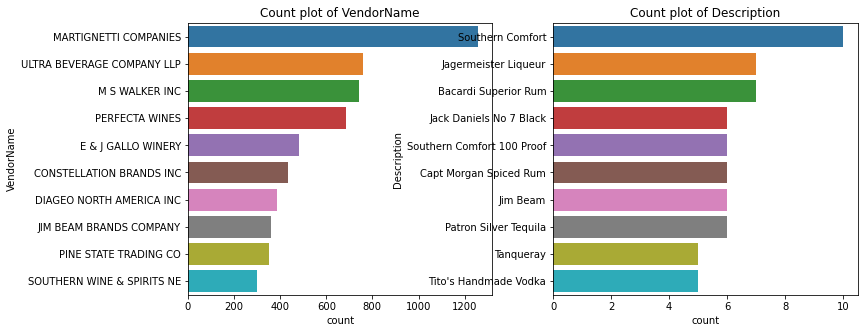

In [26]:
#  Count Plots for Categorical Columns
categorical_cols=['VendorName','Description']

plt.figure(figsize=(12,5))
for  i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) #Top 10 categories
    plt.title(f"Count plot of {col}")
plt.tight_layout
plt.show()

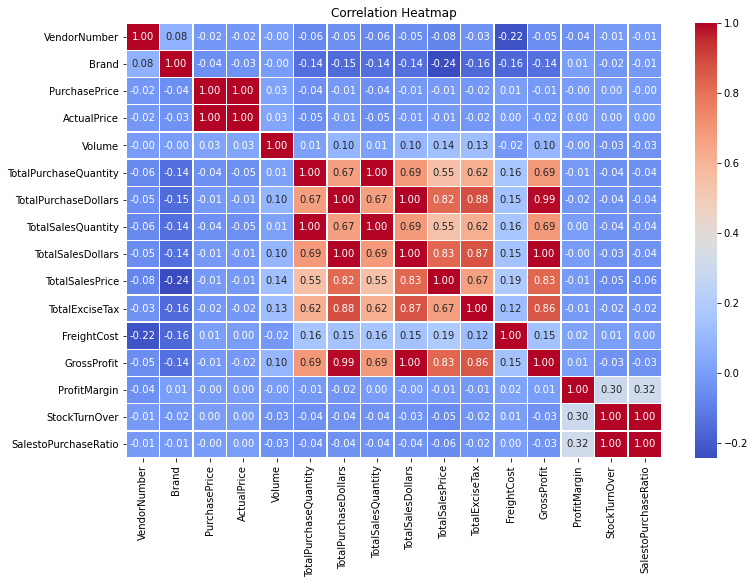

In [29]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights

- PurchasePrice has weak correlation with TotalSalesDollars(-0.01) and GrossProfit(-0.016),suggesting that price variation do not significantly impact sales revenue or profit

- TotalPurchaseDollars and TotalSalesDollars show a very strong positive correlation (1.00), indicating that higher purchasing investment is associated with higher sales revenue.

- TotalPurchaseQuantity and TotalSalesQuantity have a positive correlation (0.67), suggesting that increased purchasing generally supports increased sales.

- A weak negative correlation between Profit Margin and Total Sales Price (-0.179) suggests that increasing sales prices do not necessarily lead to higher profit margins, possibly due to competitive pricing pressures, discounting strategies, or higher procurement costs.

- Stock Turnover has weak negative correlations with Gross Profit (-0.038) and Profit Margin (-0.055), indicating that faster inventory turnover alone does not guarantee higher profitability.

### Data Analysis

#### Identify  Brands that needs Promotional or Pricing Adjustments Which exhibit lower sales performance but higher profit margins

In [31]:
brand_performance= df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [32]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)


In [33]:
low_sales_threshold

935.3200000000003

In [34]:
high_margin_threshold

79.57902614359809

In [35]:
# Filter brands with low sales nut high profit margins
target_brands=brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
7107,Santa Rita Organic Svgn Bl,19.98,83.233233
2683,Debauchery Pnt Nr,23.16,82.987910
2350,Concannon Glen Ellen Wh Zin,31.90,91.724138
2479,Crown Royal Apple,55.72,94.903087
7147,Sauza Sprklg Wild Berry Marg,55.92,91.076538
...,...,...,...
3279,Fifty Shades Of Grey Wh Silk,901.18,94.189840
6470,Poggio Amorelli Chianti Clsc,911.52,83.557135
4283,JJ Prum Bernkasteler Bads 11,917.66,84.621755
5044,Lincourt Courtney's Chard,923.16,88.171065


In [47]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

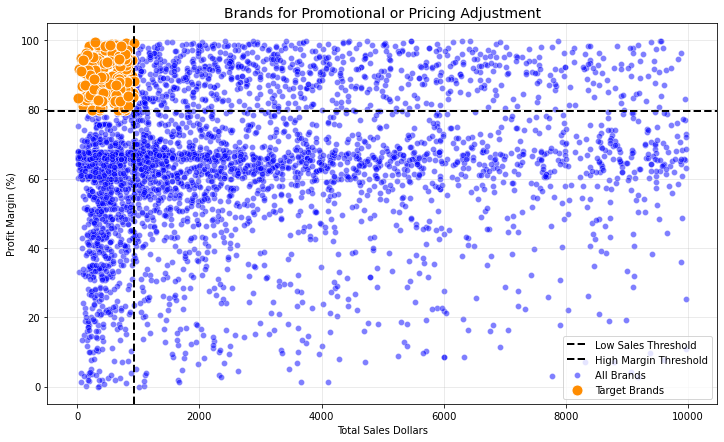

In [46]:
plt.figure(figsize=(12,7))

# All brands
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='Blue',
    alpha=0.5,
    label='All Brands'
)

# Target brands
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='darkorange',
    s=120,
    label='Target Brands'
)

# Threshold lines
plt.axvline(
    x=low_sales_threshold,
    linestyle='--',
    color='black',
    linewidth=2,
    label='Low Sales Threshold'
)

plt.axhline(
    y=high_margin_threshold,
    linestyle='--',
    color='Black',
    linewidth=2,
    label='High Margin Threshold'
)

plt.title('Brands for Promotional or Pricing Adjustment', fontsize=14)
plt.xlabel('Total Sales Dollars')
plt.ylabel('Profit Margin (%)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Which vendors and brands demonstate the highest sales  performance

In [50]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [48]:
# Top Vendors & Brands by Sales Performance
top_vendors=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10) 
top_brands=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      1.374429e+08
MARTIGNETTI COMPANIES         8.169332e+07
PERNOD RICARD USA             6.454312e+07
JIM BEAM BRANDS COMPANY       6.371413e+07
BACARDI USA INC               5.000406e+07
CONSTELLATION BRANDS INC      4.892411e+07
E & J GALLO WINERY            3.709056e+07
BROWN-FORMAN CORP             3.694439e+07
ULTRA BEVERAGE COMPANY LLP    3.537940e+07
M S WALKER INC                3.073445e+07
Name: TotalSalesDollars, dtype: float64

In [49]:
top_brands

Description
Jack Daniels No 7 Black    1.592949e+07
Tito's Handmade Vodka      1.479932e+07
Grey Goose Vodka           1.441922e+07
Capt Morgan Spiced Rum     1.271264e+07
Absolut 80 Proof           1.248950e+07
Jameson Irish Whiskey      1.143152e+07
Ketel One Vodka            1.014017e+07
Baileys Irish Cream        8.300244e+06
Kahlua                     7.209717e+06
Tanqueray                  6.913396e+06
Name: TotalSalesDollars, dtype: float64

In [52]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    15.93M
Tito's Handmade Vodka      14.80M
Grey Goose Vodka           14.42M
Capt Morgan Spiced Rum     12.71M
Absolut 80 Proof           12.49M
Jameson Irish Whiskey      11.43M
Ketel One Vodka            10.14M
Baileys Irish Cream         8.30M
Kahlua                      7.21M
Tanqueray                   6.91M
Name: TotalSalesDollars, dtype: object

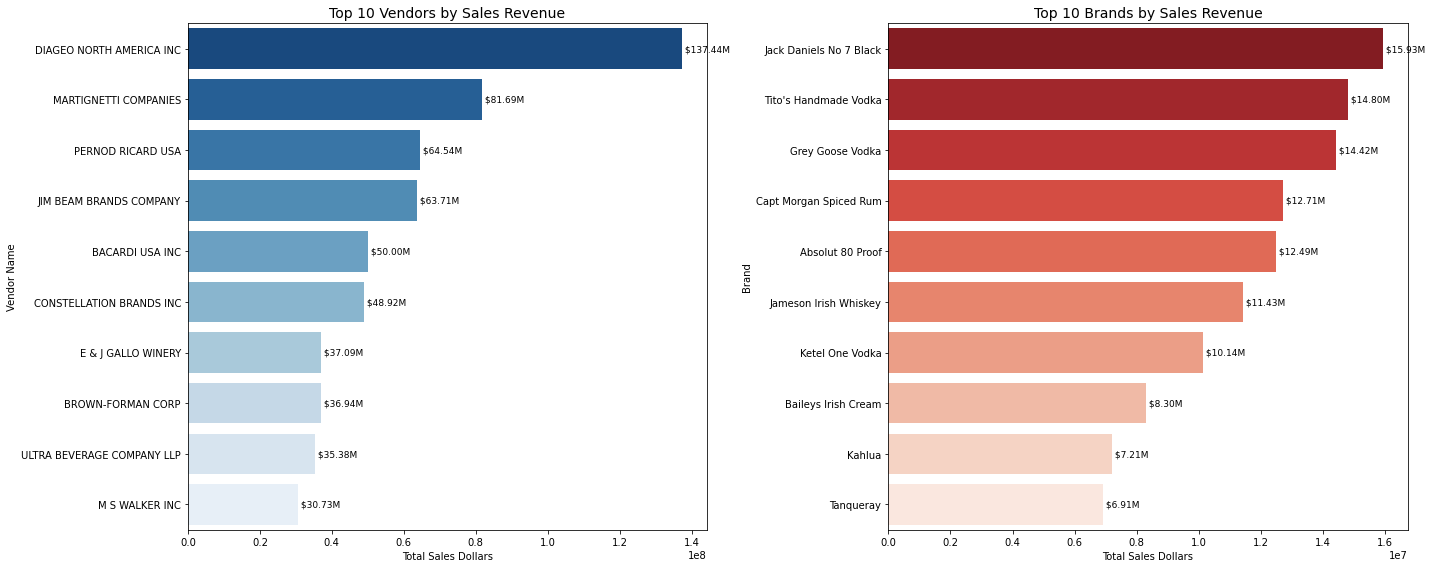

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 Vendors
top_vendors = (
    df.groupby('VendorName')['TotalSalesDollars']
      .sum()
      .nlargest(10)
)

# Top 10 Brands
top_brands = (
    df.groupby('Description')['TotalSalesDollars']
      .sum()
      .nlargest(10) 
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ---------------- Top Vendors ----------------
sns.barplot(
    x=top_vendors.values,
    y=top_vendors.index,
    palette='Blues_r',
    ax=axes[0]
)

axes[0].set_title('Top 10 Vendors by Sales Revenue', fontsize=14)
axes[0].set_xlabel('Total Sales Dollars')
axes[0].set_ylabel('Vendor Name')

# Add values on bars
for i, v in enumerate(top_vendors.values):
    axes[0].text(
        v,
        i,
        f' ${v/1_000_000:.2f}M',
        va='center',
        fontsize=9
    )

# ---------------- Top Brands ----------------
sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette='Reds_r',
    ax=axes[1]
)

axes[1].set_title('Top 10 Brands by Sales Revenue', fontsize=14)
axes[1].set_xlabel('Total Sales Dollars')
axes[1].set_ylabel('Brand')

# Add values on bars
for i, v in enumerate(top_brands.values):
    axes[1].text(
        v,
        i,
        f' ${v/1_000_000:.2f}M',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Which vendors contribute the most too total purchase dollars

In [71]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [83]:
vendor_performance['PurchaseContribution'] = (
    vendor_performance['TotalPurchaseDollars']
    / vendor_performance['TotalPurchaseDollars'].sum()
)*100

In [84]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution',ascending=False),2)

In [85]:
# Displat Top 10 Vendors
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution
26,DIAGEO NORTH AMERICA INC,50.89M,86.56M,137.44M,15.95
59,MARTIGNETTI COMPANIES,27.38M,54.31M,81.69M,8.58
70,PERNOD RICARD USA,24.10M,40.44M,64.54M,7.56
48,JIM BEAM BRANDS COMPANY,24.05M,39.67M,63.71M,7.54
7,BACARDI USA INC,17.61M,32.39M,50.00M,5.52
21,CONSTELLATION BRANDS INC,15.55M,33.37M,48.92M,4.88
12,BROWN-FORMAN CORP,13.50M,23.44M,36.94M,4.23
109,ULTRA BEVERAGE COMPANY LLP,12.65M,22.73M,35.38M,3.97
31,E & J GALLO WINERY,12.25M,24.84M,37.09M,3.84
55,M S WALKER INC,10.56M,20.18M,30.73M,3.31


In [86]:
top_vendors['Cumulative_Contributions']=top_vendors['PurchaseContribution'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution,Cumulative_Contributions
26,DIAGEO NORTH AMERICA INC,50.89M,86.56M,137.44M,15.95,15.95
59,MARTIGNETTI COMPANIES,27.38M,54.31M,81.69M,8.58,24.53
70,PERNOD RICARD USA,24.10M,40.44M,64.54M,7.56,32.09
48,JIM BEAM BRANDS COMPANY,24.05M,39.67M,63.71M,7.54,39.63
7,BACARDI USA INC,17.61M,32.39M,50.00M,5.52,45.15
21,CONSTELLATION BRANDS INC,15.55M,33.37M,48.92M,4.88,50.03
12,BROWN-FORMAN CORP,13.50M,23.44M,36.94M,4.23,54.26
109,ULTRA BEVERAGE COMPANY LLP,12.65M,22.73M,35.38M,3.97,58.23
31,E & J GALLO WINERY,12.25M,24.84M,37.09M,3.84,62.07
55,M S WALKER INC,10.56M,20.18M,30.73M,3.31,65.38


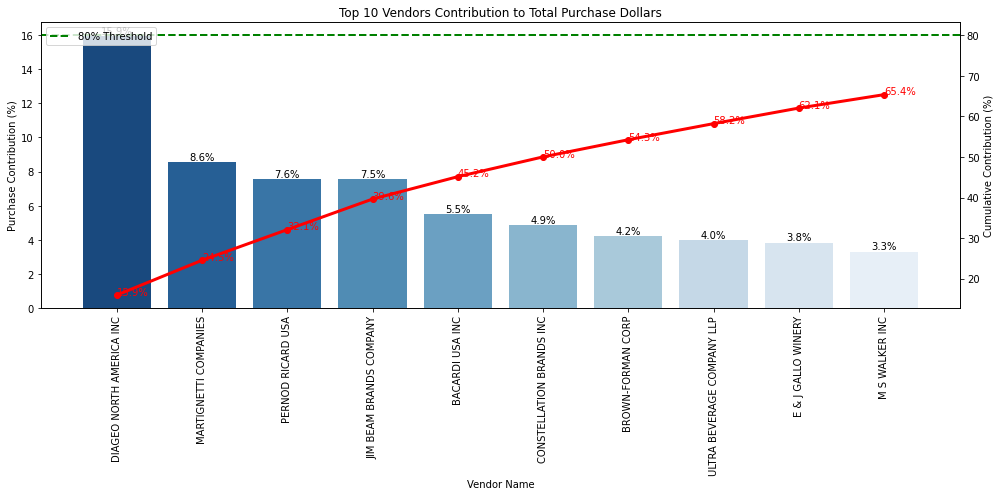

In [90]:


# Top 10 vendors by purchase contribution
top_vendors = (
    vendor_performance
    .head(10)
    .copy()
)

# Cumulative contribution
top_vendors['CumulativeContribution'] = (
    top_vendors['PurchaseContribution'].cumsum()
)

fig, ax1 = plt.subplots(figsize=(14,7))

# Bar Plot
sns.barplot(
    data=top_vendors,
    x='VendorName',
    y='PurchaseContribution',
    palette='Blues_r',
    ax=ax1
)

ax1.set_ylabel('Purchase Contribution (%)')
ax1.set_xlabel('Vendor Name')
ax1.set_title('Top 10 Vendors Contribution to Total Purchase Dollars')
ax1.tick_params(axis='x', rotation=90)

# Add values on bars
for i, v in enumerate(top_vendors['PurchaseContribution']):
    ax1.text(
        i,
        v,
        f'{v:.1f}%',
        ha='center',
        va='bottom'
    )

# Line Plot
ax2 = ax1.twinx()

ax2.plot(
    range(len(top_vendors)),
    top_vendors['CumulativeContribution'],
    color='red',
    marker='o',
    linewidth=3
)

# Add cumulative labels
for i, v in enumerate(top_vendors['CumulativeContribution']):
    ax2.text(
        i,
        v,
        f'{v:.1f}%',
        color='red'
    )

ax2.set_ylabel('Cumulative Contribution (%)')
ax2.axhline(
    y=80,
    color='green',
    linestyle='--',
    linewidth=2,
    label='80% Threshold'
)

ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

#### How much of total procurement is dependent on top vendors

In [91]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.38 %


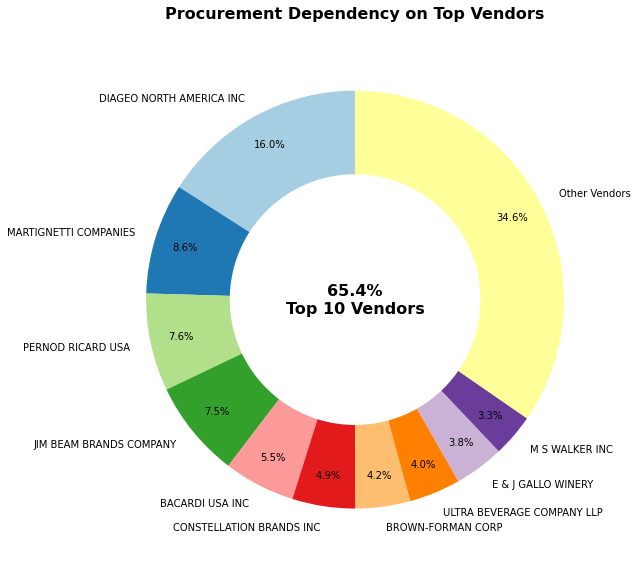

In [95]:
# Top 10 Vendors
top_vendors = (
    vendor_performance
    .head(10)
    .copy()
)

# Prepare data
vendors = list(top_vendors['VendorName'].values)
purchase_contribution = list(top_vendors['PurchaseContribution'].values)

total_contribution = sum(purchase_contribution)
remaining_contribution = 100 - total_contribution

# Add Other Vendors category
vendors.append("Other Vendors")
purchase_contribution.append(remaining_contribution)

# Create Donut Chart
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contribution,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4),
    colors=plt.cm.Paired.colors
)

# Center Annotation
ax.text(
    0,
    0,
    f'{total_contribution:.1f}%\nTop 10 Vendors',
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

# Title
ax.set_title(
    'Procurement Dependency on Top Vendors',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()


#### Does purchasing bulk reduce the unit price, and what is the optional purchase volume for cost saving

In [96]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [100]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['small','medium','large'])

In [103]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,large,145080
1,large,164038
2,large,187407
3,large,201682
4,large,138109
...,...,...
9810,small,2
9811,small,6
9812,small,2
9813,small,1


In [104]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
small,39.551050
medium,16.822524
large,11.115914


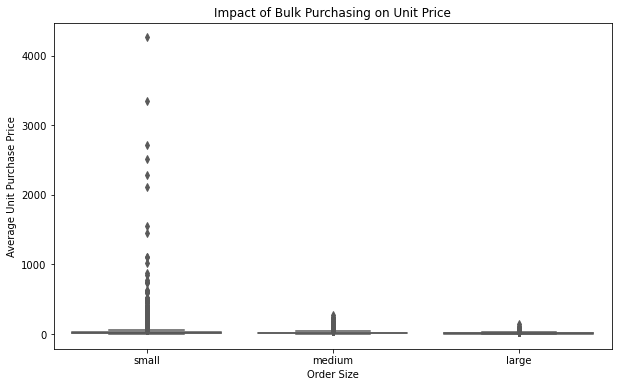

In [105]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="OrderSize",y='UnitPurchasePrice',palette='Set2')
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Bulk purchasing reduces unit costs significantly. Large orders achieve the lowest average purchase price ($11.12 per unit), suggesting that vendors benefit from economies of scale and volume-based pricing discounts.

- The difference in average unit purchase price between small and large orders is substantial, with large orders achieving approximately a 72% reduction in unit cost

- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales volumes despite lower revenue per unit.-

#### Which vendors have low inventory turnover, indicating excess stock and slow-moving products

In [109]:
df[df['StockTurnOver'] < 1] \
    .groupby('VendorName')[['StockTurnOver']] \
    .mean() \
    .sort_values(by='StockTurnOver',ascending=True).head(10)

,StockTurnOver
VendorName,
SURVILLE ENTERPRISES CORP,0.666667
UNCORKED,0.718750
THE PIERPONT GROUP LLC,0.722222
MOET HENNESSY USA INC,0.750000
VRANKEN AMERICA,0.764331
REMY COINTREAU USA INC,0.769231
CONSTELLATION BRANDS INC,0.773855
BANFI PRODUCTS CORP,0.777778
DIAGEO CHATEAU ESTATE WINES,0.783333


#### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it

In [120]:
print(
    "Total Unsold Capital:",
    format_dollars(df['UnsoldInventoryValue'].sum())
)

df.nlargest(
    10,
    'UnsoldInventoryValue'
)[[
    'VendorName',
    'Description',
    'UnsoldUnits',
    'UnsoldInventoryValue'
]]

Total Unsold Capital: 216.19K


,VendorName,Description,UnsoldUnits,UnsoldInventoryValue
2296,MARTIGNETTI COMPANIES,Bouchaine Pnt Nr Carneros,794.0,8956.32
2742,MARTIGNETTI COMPANIES,Far Niente Cab Svgn Napa,87.0,7950.06
1679,MARTIGNETTI COMPANIES,Sanford Santa Rita Pnt Nr,390.0,5822.70
2799,ULTRA BEVERAGE COMPANY LLP,Victor Vineyards Cab Svgn 13,861.0,5553.45
1562,JIM BEAM BRANDS COMPANY,Knob Creek 2001 Bourbon,43.0,4109.94
3105,FREDERICK WILDMAN & SONS,Jaboulet Cts Rhone Parl Rose,509.0,3491.74
2838,CAMPARI AMERICA,Campari Negroni,130.0,3296.80
3374,ULTRA BEVERAGE COMPANY LLP,Januik Muscat Canelli Champx,616.0,3283.28
2055,ULTRA BEVERAGE COMPANY LLP,Stonehedge Meritage 13 Napa,283.0,3214.88
3147,PERNOD RICARD USA,Avion Reposado Tequila,92.0,3134.44


In [121]:
# Aggregate capital locked per Vendor
inventory_value_per_vendor=df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

# Sort vendors with the highest Locked Capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by='UnsoldInventoryValue',ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
59,MARTIGNETTI COMPANIES,59.19K
109,ULTRA BEVERAGE COMPANY LLP,31.87K
69,PERFECTA WINES,30.14K
48,JIM BEAM BRANDS COMPANY,11.40K
55,M S WALKER INC,10.42K
38,FREDERICK WILDMAN & SONS,8.44K
72,PINE STATE TRADING CO,8.28K
90,SOUTHERN WINE & SPIRITS NE,4.31K
21,CONSTELLATION BRANDS INC,4.05K
83,SEA BREEZE CELLARS LLC,3.89K


#### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors

In [122]:
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

In [123]:
top_vendors=df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_threshold]['ProfitMargin'].dropna()

In [124]:
top_vendors

0       62.648846
1       60.531405
2       62.337893
3       63.569954
4       64.206382
          ...    
4189    89.408894
4683    92.986408
5302    96.542930
5513    97.506265
5664    97.135929
Name: ProfitMargin, Length: 2454, dtype: float64

In [125]:
low_vendors

5885     8.347816
5913     6.618451
5980    14.822289
6014    12.856129
6015    16.532795
          ...    
9810    91.724138
9811    98.218093
9812    62.626263
9813    99.487018
9814    99.583040
Name: ProfitMargin, Length: 2454, dtype: float64

In [131]:
def confidence_interval(data, confidence=0.95):
    mean_val=np.mean(data)
    std_err=np.std(data, ddof=1)/np.sqrt(len(data)) # Standard error
    t_critical=stats.t.ppf((1 + confidence)/2 ,df=len(data)-1)
    margin_of_error=t_critical * std_err
    return mean_val, mean_val- margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (64.83, 65.33), Mean: 65.08
Low Vendors 95% CI: (60.89, 62.50), Mean: 61.69


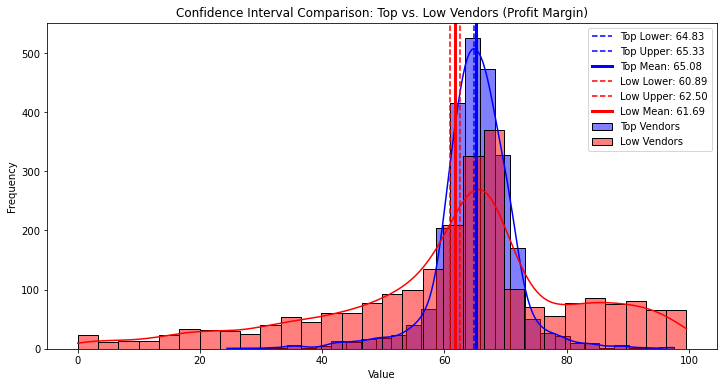

In [133]:

top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(
    f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}"
)
print(
    f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}"
)

# Plot
plt.figure(figsize=(12,6))

# Top Vendors Distribution
sns.histplot(
    top_vendors,
    kde=True,
    color='blue',
    bins=30,
    alpha=0.5,
    label='Top Vendors'
)

# Low Vendors Distribution
sns.histplot(
    low_vendors,
    kde=True,
    color='red',
    bins=30,
    alpha=0.5,
    label='Low Vendors'
)

# Top Vendor CI
plt.axvline(
    top_lower,
    color='blue',
    linestyle='--',
    label=f'Top Lower: {top_lower:.2f}'
)

plt.axvline(
    top_upper,
    color='blue',
    linestyle='--',
    label=f'Top Upper: {top_upper:.2f}'
)

plt.axvline(
    top_mean,
    color='blue',
    linewidth=3,
    label=f'Top Mean: {top_mean:.2f}'
)

# Low Vendor CI
plt.axvline(
    low_lower,
    color='red',
    linestyle='--',
    label=f'Low Lower: {low_lower:.2f}'
)

plt.axvline(
    low_upper,
    color='red',
    linestyle='--',
    label=f'Low Upper: {low_upper:.2f}'
)

plt.axvline(
    low_mean,
    color='red',
    linewidth=3,
    label=f'Low Mean: {low_mean:.2f}'
)

plt.title('Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

- Increase focus on high-performing vendors as they generate higher sales and profits for the business.

- Review low-performing vendors and products to identify reasons for low sales and slow inventory movement.

- Reduce prices slightly for high-margin but low-sales products to attract more customers and increase sales volume.

- Clear slow-moving inventory through promotions and discounts to reduce unsold stock and improve cash flow.

#### Is there a significant difference in profit margins between top-performing and low-performing vendors

##### Hypothesis:

- H0 (Null Hypothesis): There is no significant in the mean profit margins of top-performing and low-performing vendors

- H1 (Alternative Hypothesis): The mean Profit margins of top-performing and low-performing vendors are significantly different

In [138]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(
    top_vendors,
    low_vendors,
    equal_var=False
)

# Print Results
print(f'T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}')

if p_value < 0.05:
    print('Reject H0: There is a significant difference in profit margins between top and low-performing vendors.')
else:
    print('Fail to Reject H0: No significant difference in profit margins between top and low-performing vendors.')

T-Statistic: 7.8808, P-Value: 0.0000
Reject H0: There is a significant difference in profit margins between top and low-performing vendors.


- The analysis confirms that vendor performance has a significant impact on profit margins. High-performing vendors generate better profitability and should be prioritized in procurement and sales strategies.